In [1]:
# pip install nsepy

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for nsepy: filename=nsepy-0.8-py3-none-any.whl size=36106 sha256=ad840ed3f40cdc78c62cd1bb3e0bf61acb444cd0d65892a24190bf933a4db5d5
  Stored in directory: c:\users\admin\appdata\local\pip\cache\wheels\bd\f8\2e\0716a91d7ea04b0022844c83db51d3f05c95fcc0099efeeefd
Successfully built nsepy
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [4]:
skt=pd.read_csv('Tatacoffee13_21.csv')

In [7]:
skt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2225 non-null   object 
 1   Open    2225 non-null   float64
 2   High    2225 non-null   float64
 3   Low     2225 non-null   float64
 4   Close   2225 non-null   float64
dtypes: float64(4), object(1)
memory usage: 87.0+ KB


In [ ]:
skt.info()

In [8]:
skt

,Date,Open,High,Low,Close
0,2013-01-01,1410.60,1427.90,1408.30,1415.10
1,2013-01-02,1421.00,1626.60,1416.15,1607.40
2,2013-01-03,1632.55,1673.90,1613.05,1626.20
3,2013-01-04,1627.75,1627.75,1574.60,1579.05
4,2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...,...
2220,2021-12-22,202.90,207.80,201.35,205.00
2221,2021-12-23,206.00,206.85,202.05,202.95
2222,2021-12-24,203.90,203.90,199.35,201.00
2223,2021-12-27,200.00,222.00,196.00,218.35


In [9]:
Low=skt["Low"]

In [15]:
from Descriptive import DescriptiveAnalysis

obj = DescriptiveAnalysis()

dataset = skt

quan, qual = obj.qual_quan(dataset)

print("Quantitative:", quan)
print("Qualitative:", qual)

Quantitative: ['Open', 'High', 'Low', 'Close']
Qualitative: ['Date']


In [20]:
desc=DescriptiveAnalysis.Univariate(quan,dataset)
desc

,Open,High,Low,Close
Mean,340.559393,346.094337,335.565528,339.695663
Median,118.85,121.4,116.7,118.65
Mode,91.0,93.0,91.0,90.75
Q1:25%,92.6,94.0,91.35,92.3
Q2:50%,118.85,121.4,116.7,118.65
Q3:75%,212.0,215.0,207.95,212.3
Q4:100%,1651.0,1679.7,1636.95,1648.2
%99,1587.342,1610.9,1565.14,1586.386
IQR,119.4,121.0,116.6,120.0
1.5rule,179.1,181.5,174.9,180.0


In [21]:
desc["Low"]


Mean           335.565528
Median              116.7
Mode                 91.0
Q1:25%              91.35
Q2:50%              116.7
Q3:75%             207.95
Q4:100%           1636.95
%99               1565.14
IQR                 116.6
1.5rule             174.9
Lesser             -83.55
Greater            382.85
Max               1636.95
Min                  48.0
Skewness         1.555376
Kurtosis         0.984385
Variance    180071.908229
Std            424.348805
Name: Low, dtype: object

In [22]:
desc["High"]

Mean           346.094337
Median              121.4
Mode                 93.0
Q1:25%               94.0
Q2:50%              121.4
Q3:75%              215.0
Q4:100%            1679.7
%99                1610.9
IQR                 121.0
1.5rule             181.5
Lesser              -87.5
Greater             396.5
Max                1679.7
Min                  50.9
Skewness         1.554608
Kurtosis         0.978422
Variance    190900.090298
Std            436.921149
Name: High, dtype: object

In [26]:
import numpy as np

In [27]:
np.percentile(dataset["Low"],99)

np.float64(1565.1399999999996)

In [28]:
np.percentile(dataset["High"],99)

np.float64(1610.8999999999996)

In [30]:
def get_pdf_probability(dataset, startrange, endrange):

    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns

    ax = sns.distplot(
        dataset,
        kde=True,
        kde_kws={'color': 'blue'},
        color='Green'
    )

    pyplot.axvline(startrange, color='Red')
    pyplot.axvline(endrange, color='Red')

    # generate a sample
    sample = dataset

    # calculate parameters
    sample_mean = sample.mean()
    sample_std = sample.std()

    print(
        "Mean: %.3f, Standard Deviation: %.3f"
        % (sample_mean, sample_std)
    )

    # define the distribution
    dist = norm(sample_mean, sample_std)

    # sample probabilities for a range of outcomes
    values = [
        value for value in range(startrange, endrange)
    ]

    probabilities = [
        dist.pdf(value) for value in values
    ]

    prob = sum(probabilities)

    print(
        "The area between range({0},{1}) = {2}".format(
            startrange,
            endrange,
            sum(probabilities)
        )
    )

    return prob

C:\Users\admin\AppData\Local\Temp\ipykernel_16644\698005147.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(


Mean: 335.566, Standard Deviation: 424.349
The area between range(218,230) = 0.010894581398137738


np.float64(0.010894581398137738)

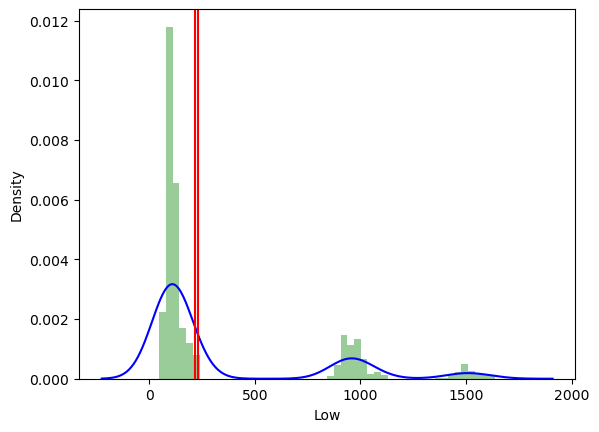

In [31]:
 get_pdf_probability(dataset["Low"],218,230)

In [33]:
def stdNBgraph(dataset):
    
    import seaborn as sns

    mean = dataset.mean()
    std = dataset.std()

    values = [i for i in dataset]

    z_score = [(i - mean) / std for i in values]

    sns.distplot(z_score, kde=True)

    sum(z_score) / len(z_score)

   

C:\Users\admin\AppData\Local\Temp\ipykernel_16644\333608481.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score, kde=True)


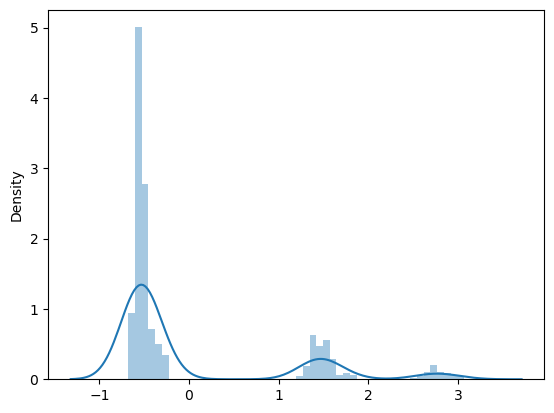

In [34]:
stdNBgraph(dataset["Low"])

In [35]:
def freqTable(columnName, dataset):
    import pandas as pd

    frq = pd.DataFrame()

    frq["Unique_Values"] = dataset[columnName].value_counts().index
    frq["Frequency"] = dataset[columnName].value_counts().values
    frq["Relative_Frequency"] = (
        dataset[columnName].value_counts().values
        / len(dataset[columnName])
    ) * 100
    frq["Cumulative_Frequency"] = frq["Relative_Frequency"].cumsum()

    return frq

In [36]:
freqTable("Low", dataset)

,Unique_Values,Frequency,Relative_Frequency,Cumulative_Frequency
0,91.00,10,0.449438,0.449438
1,87.50,9,0.404494,0.853933
2,90.10,9,0.404494,1.258427
3,86.50,9,0.404494,1.662921
4,89.10,8,0.359551,2.022472
...,...,...,...,...
1435,90.95,1,0.044944,99.820225
1436,85.20,1,0.044944,99.865169
1437,85.95,1,0.044944,99.910112
1438,86.60,1,0.044944,99.955056


In [41]:
fh=freqTable("High",dataset)

In [42]:
fh.sort_values(by="Frequency", ascending=False)

,Unique_Values,Frequency,Relative_Frequency,Cumulative_Frequency
0,93.00,11,0.494382,0.494382
2,95.40,9,0.404494,1.303371
3,91.80,9,0.404494,1.707865
1,113.40,9,0.404494,0.898876
4,90.50,7,0.314607,2.022472
...,...,...,...,...
780,129.15,1,0.044944,69.617978
781,95.30,1,0.044944,69.662921
782,126.75,1,0.044944,69.707865
783,93.10,1,0.044944,69.752809


In [43]:
fh[fh["Frequency"] == 2]["Unique_Values"].sort_values(ascending=False)

410    1525.00
370    1511.95
372    1510.00
389    1470.00
364    1130.00
        ...   
205      74.05
362      73.20
204      72.95
206      72.85
384      59.00
Name: Unique_Values, Length: 253, dtype: float64